In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import TruncatedSVD
import umap
from scipy.spatial.distance import cdist

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("✓ Libraries loaded")

✓ Libraries loaded


## Obj:  build a recommendation system using the techniques from the lectures: collaborative filtering and matrix factorisation

# Load the Data

In [5]:
# Load the dataset
df_movies = pd.read_csv('C:\\Users\\ballo\\Desktop\\Unistra\\M2\\ML\\DL2 diletta\\Assignement2\\ml-25m\\ml-25m\\movies.csv')
df_ratings = pd.read_csv('C:\\Users\\ballo\\Desktop\\Unistra\\M2\\ML\\DL2 diletta\\Assignement2\\ml-25m\\ml-25m\\ratings.csv')

In [6]:
print(df_movies.head())

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [7]:
print(df_ratings.head())

   userId  movieId  rating   timestamp
0       1      296     5.0  1147880044
1       1      306     3.5  1147868817
2       1      307     5.0  1147868828
3       1      665     5.0  1147878820
4       1      899     3.5  1147868510


Note: In df_rating we have the interaction (link) between User and Movie. it's the table which will be use for user-item matrix

In [39]:
def build_user_item_matrix_simple(df_ratings):
    """
    Construire une USER-ITEM MATRIX à partir des données de ratings.
    """
    # Étape 1: Extraire les indices et les valeurs des données
    row_indices = df_ratings['userId'].values - 1      # Index des utilisateurs (ligne)
    col_indices = df_ratings['movieId'].values - 1     # Index des films (colonne)
    ratings = df_ratings['rating'].values              # Valeurs des ratings
    
    # Étape 2: Déterminer la taille de la matrice
    n_users = df_ratings['userId'].max()               # Nombre total d'utilisateurs
    n_movies = df_ratings['movieId'].max()             # Nombre total de films
    
    # Étape 3: Créer la matrice sparse (CSR = Compressed Sparse Row)
    # C'est plus efficace qu'une matrice dense car elle ne stocke que les valeurs non-nulles
    user_item_matrix = csr_matrix((ratings, (row_indices, col_indices)), 
                                   shape=(n_users, n_movies))
    
    return user_item_matrix, n_users, n_movies


# Tester la fonction
print("=" * 60)
print("CONSTRUCTION DE LA USER-ITEM MATRIX")
print("=" * 60)

user_item_matrix, n_users, n_movies = build_user_item_matrix_simple(df_ratings)

print(f"\n✓ Matrix créée avec succès!")
print(f"\nDimensions:")
print(f"  - Nombre d'utilisateurs: {n_users}")
print(f"  - Nombre de films: {n_movies}")
print(f"  - Taille totale: {n_users} Users (rows) × {n_movies} Movies (cols) = {n_users * n_movies:,} cellules")
print(f"\nRatings : {user_item_matrix.nnz:,} intéractions")
print(f"Sparsity: {(n_users * n_movies) - user_item_matrix.nnz:,} de cellules vides")
# Sparsity en pourcentage
sparsity_percentage = ((n_users * n_movies - user_item_matrix.nnz) / (n_users * n_movies)) * 100
print(f"  - soit : {sparsity_percentage:.2f}% de cellules vides")


CONSTRUCTION DE LA USER-ITEM MATRIX

✓ Matrix créée avec succès!

Dimensions:
  - Nombre d'utilisateurs: 162541
  - Nombre de films: 209171
  - Taille totale: 162541 Users (rows) × 209171 Movies (cols) = 33,998,863,511 cellules

Ratings : 25,000,095 intéractions
Sparsity: 33,973,863,416 de cellules vides
  - soit : 99.93% de cellules vides


In [40]:
user_item_matrix[:50, :50]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 178 stored elements and shape (50, 50)>

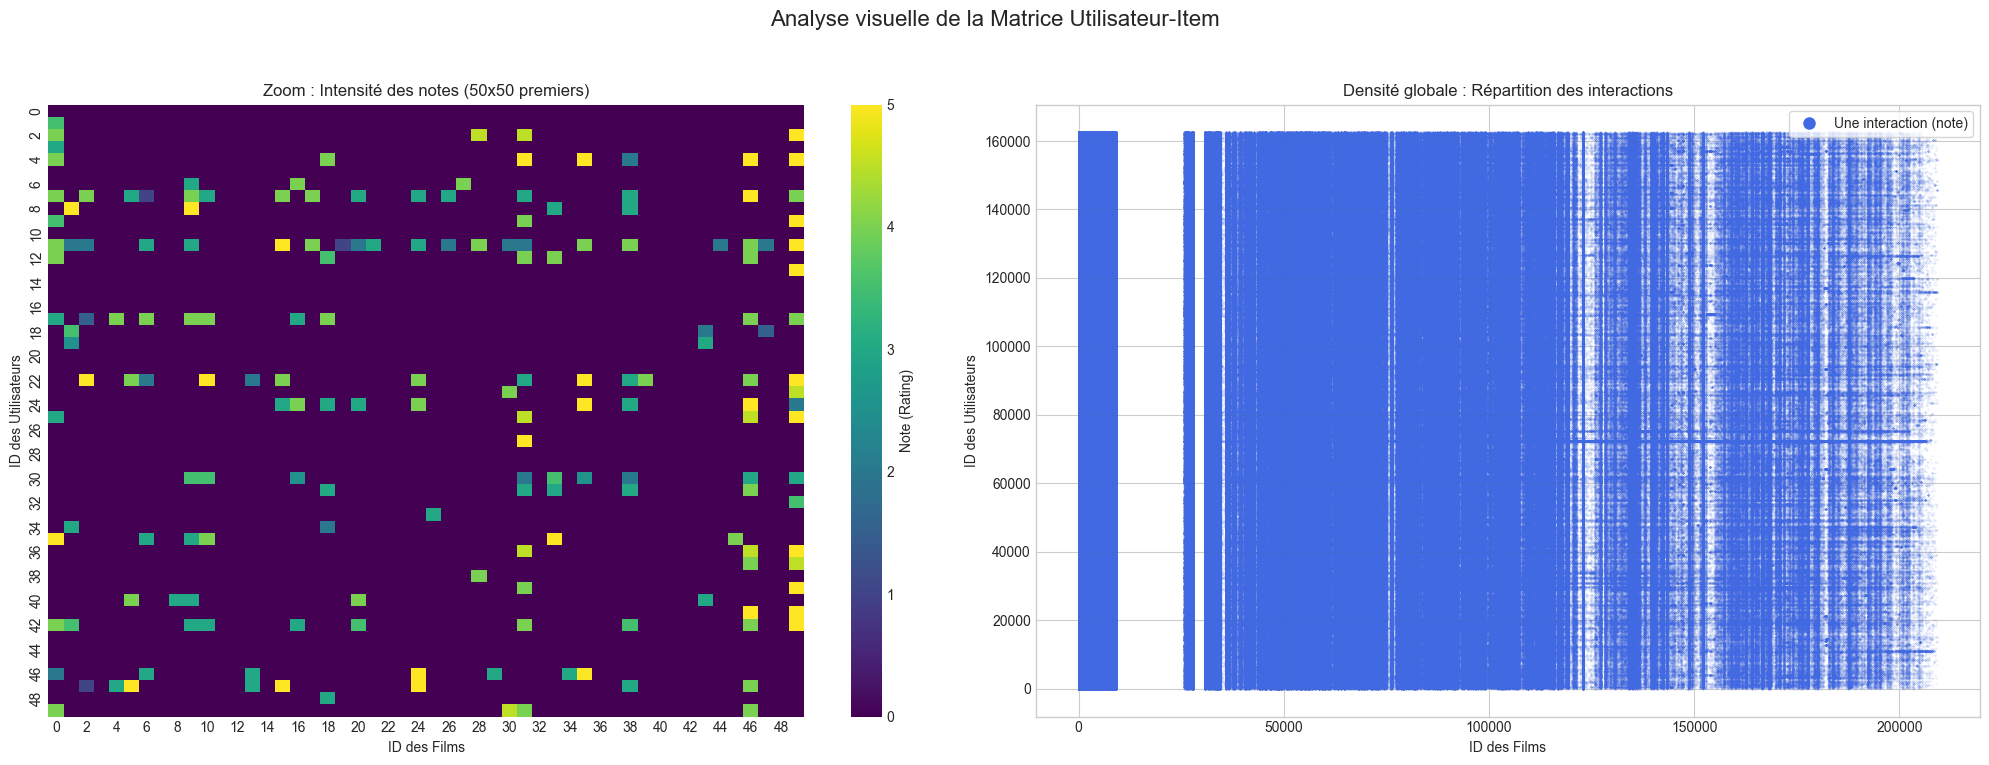

In [53]:
# On définit la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- 1. HEATMAP (À GAUCHE) ---
# cbar=True affiche la légende des couleurs (l'échelle des notes)
sns.heatmap(user_item_matrix[:50, :50].toarray(), 
            cmap='viridis', 
            cbar=True, 
            cbar_kws={'label': 'Note (Rating)'}, # Titre de la légende
            ax=ax1)
ax1.set_title('Zoom : Intensité des notes (50x50 premiers)')
ax1.set_xlabel('ID des Films')
ax1.set_ylabel('ID des Utilisateurs')

# --- 2. SPARSITY (À DROITE) ---
users_idx, movies_idx = user_item_matrix.nonzero()

# On crée le nuage de points
scatter = ax2.scatter(movies_idx, users_idx, alpha=0.3, s=0.05, color='royalblue', label='Note existante')

# Création d'une légende personnalisée pour le scatter plot
# Comme les points sont minuscules (s=0.05), on crée un point plus gros pour la légende
blue_dot = mlines.Line2D([], [], color='royalblue', marker='o', linestyle='None',
                          markersize=8, label='Une interaction (note)')

ax2.legend(handles=[blue_dot], loc='upper right', frameon=True)

ax2.set_title('Densité globale : Répartition des interactions')
ax2.set_xlabel('ID des Films')
ax2.set_ylabel('ID des Utilisateurs')

# On ajoute un titre général à la figure
plt.suptitle('Analyse visuelle de la Matrice Utilisateur-Item', fontsize=16)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste l'espace pour le titre général
plt.show()

Text(0.5, 1.0, 'Distribution des Ratings')

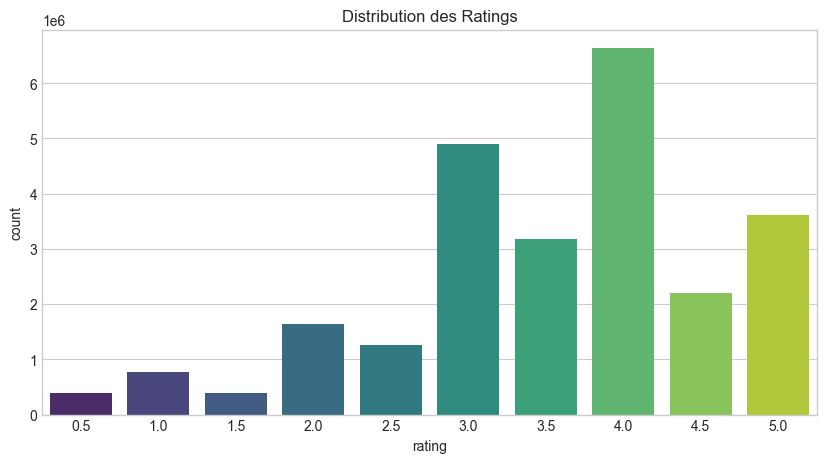

In [55]:
# Affichage de la distribution des ratings
plt.figure(figsize=(10, 5))
sns.countplot(x='rating', data=df_ratings, palette='viridis')
plt.title('Distribution des Ratings')

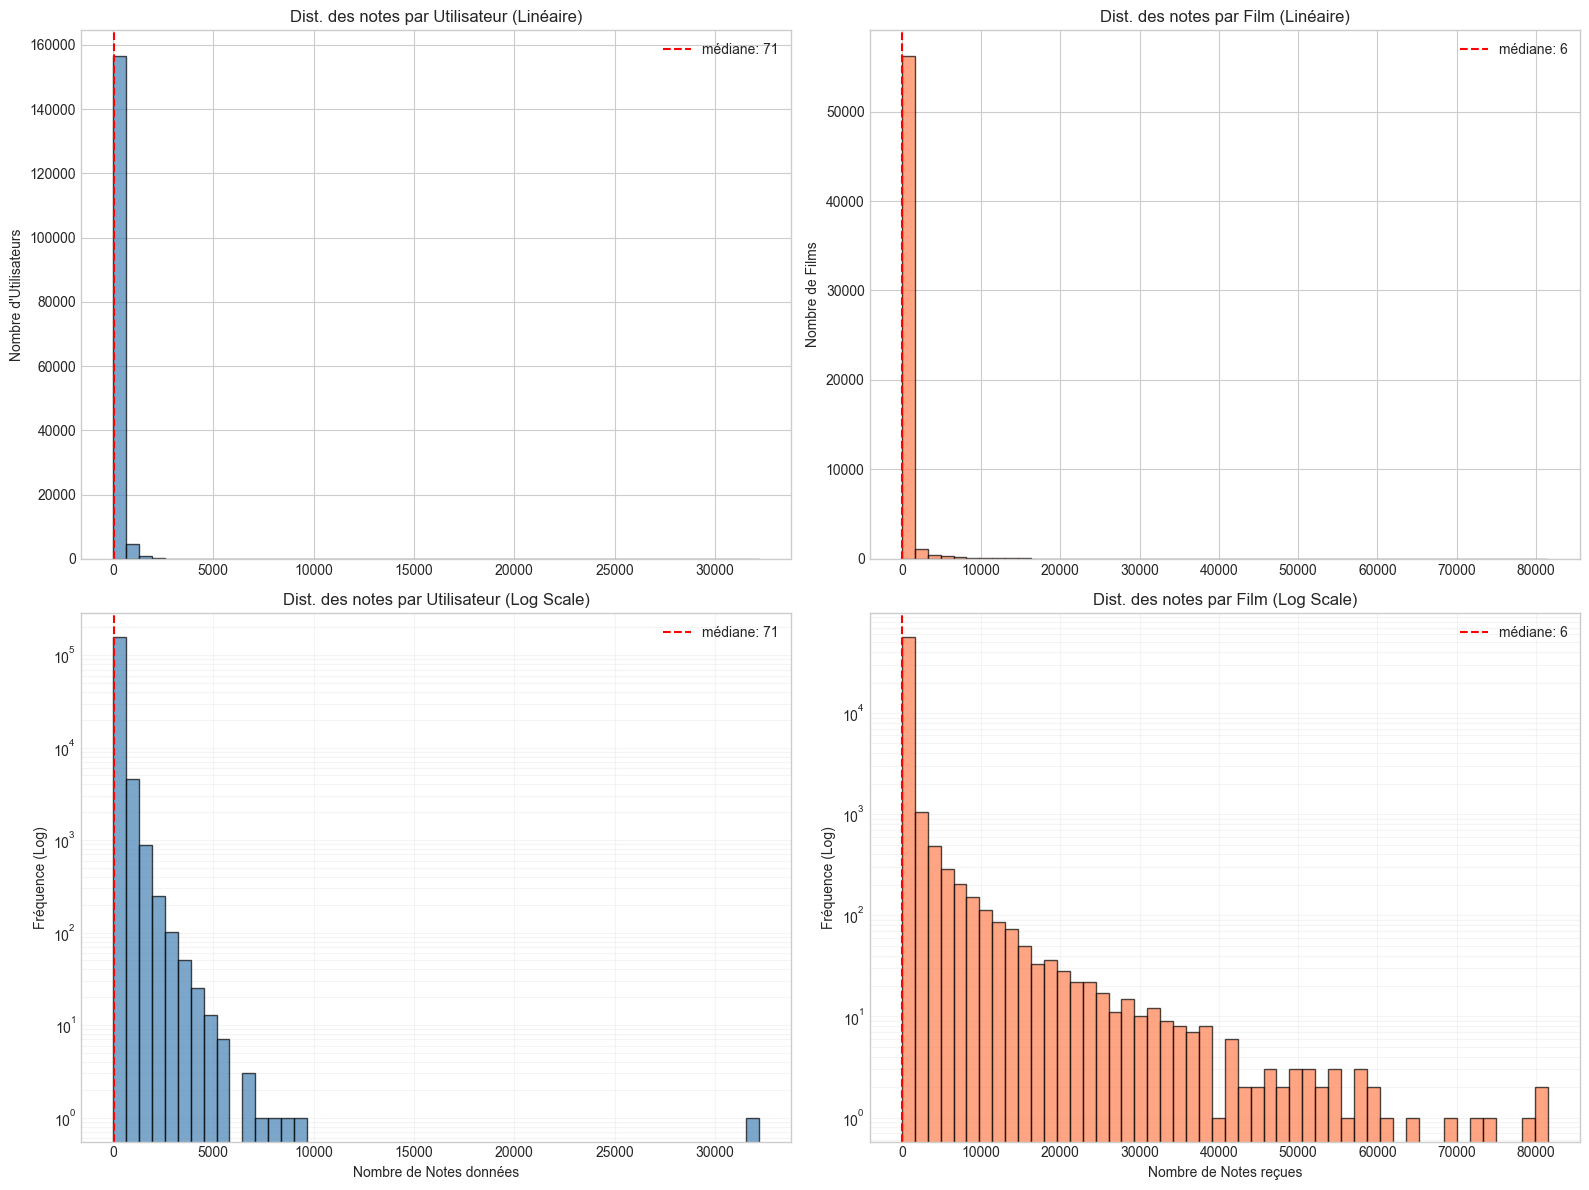

Ratings per User Statistics:
  Mean: 153.8
  Median: 71.0
  Min: 20
  Max: 32202

Ratings per Movie Statistics:
  Mean: 423.4
  Median: 6.0
  Min: 1
  Max: 81491


In [57]:
# 1. Calculs
ratings_per_user = df_ratings.groupby('userId').size()
ratings_per_movie = df_ratings.groupby('movieId').size()

# 2. Création de la figure (2 lignes, 2 colonnes)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- LIGNE 1 : ÉCHELLE NORMALE (Linéaire) ---

# Distribution par Utilisateur
axes[0, 0].hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_title('Dist. des notes par Utilisateur (Linéaire)')
axes[0, 0].set_ylabel('Nombre d\'Utilisateurs')
axes[0, 0].axvline(ratings_per_user.median(), color='red', linestyle='--', label=f'médiane: {ratings_per_user.median():.0f}')
axes[0, 0].legend()

# Distribution par Film
axes[0, 1].hist(ratings_per_movie, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Dist. des notes par Film (Linéaire)')
axes[0, 1].set_ylabel('Nombre de Films')
axes[0, 1].axvline(ratings_per_movie.median(), color='red', linestyle='--', label=f'médiane: {ratings_per_movie.median():.0f}')
axes[0, 1].legend()

# --- LIGNE 2 : ÉCHELLE LOGARITHMIQUE ---
# On utilise log=True dans le hist() ou on change l'échelle de l'axe

# Distribution par Utilisateur (Log)
axes[1, 0].hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7, color='steelblue', log=True)
axes[1, 0].set_title('Dist. des notes par Utilisateur (Log Scale)')
axes[1, 0].set_xlabel('Nombre de Notes données')
axes[1, 0].set_ylabel('Fréquence (Log)')
axes[1, 0].axvline(ratings_per_user.median(), color='red', linestyle='--', label=f'médiane: {ratings_per_user.median():.0f}')
axes[1, 0].legend()
axes[1, 0].grid(True, which="both", ls="-", alpha=0.2)

# Distribution par Film (Log)
axes[1, 1].hist(ratings_per_movie, bins=50, edgecolor='black', alpha=0.7, color='coral', log=True)
axes[1, 1].set_title('Dist. des notes par Film (Log Scale)')
axes[1, 1].set_xlabel('Nombre de Notes reçues')
axes[1, 1].set_ylabel('Fréquence (Log)')
axes[1, 1].axvline(ratings_per_movie.median(), color='red', linestyle='--', label=f'médiane: {ratings_per_movie.median():.0f}')
axes[1, 1].legend()
axes[1, 1].grid(True, which="both", ls="-", alpha=0.2)



plt.tight_layout()
plt.show()


print("Ratings per User Statistics:")
print(f"  Mean: {ratings_per_user.mean():.1f}")
print(f"  Median: {ratings_per_user.median():.1f}")
print(f"  Min: {ratings_per_user.min()}")
print(f"  Max: {ratings_per_user.max()}")
print(f"\nRatings per Movie Statistics:")
print(f"  Mean: {ratings_per_movie.mean():.1f}")
print(f"  Median: {ratings_per_movie.median():.1f}")
print(f"  Min: {ratings_per_movie.min()}")
print(f"  Max: {ratings_per_movie.max()}")

In [58]:
# Filtre : On ne garde que les user ayant au moins 50 évaluation et on ne garde que les film ayant au moins 50 éval
filtered_users = ratings_per_user[ratings_per_user >= 50].index
filtered_movies = ratings_per_movie[ratings_per_movie >= 50].index

# Nouvelles dimensions et la spasité après filtrage
n_filtered_users = len(filtered_users)
n_filtered_movies = len(filtered_movies)
filtered_ratings = df_ratings[df_ratings['userId'].isin(filtered_users) & df_ratings['movieId'].isin(filtered_movies)]
sparsity = 1 - (len(filtered_ratings) / (n_filtered_users * n_filtered_movies))
print(f"Dimensions après filtrage : {n_filtered_users} utilisateurs, {n_filtered_movies} films")
print(f"Sparsité : {sparsity:.2%}")

Dimensions après filtrage : 102492 utilisateurs, 13176 films
Sparsité : 98.31%


# 4. Collaborative Filtering

On va implémenter un User-Based et Item-based pour le collaborative filtering

In [ ]:
def search_movie(title_query, movies_df):
    """recherche de films"""
    results = movies_df[movies_df['title'].str.contains(title_query, case=False, na=False)]
    return results[['movieId', 'title', 'genres']]


print("The Greatest Showman")
print(search_movie('The Greatest Showman', df_movies))

print("\nThe Lion King")
print(search_movie("The lion King", df_movies))

print('\nI want to eat your pancreas')
print(search_movie('I Want to Eat Your Pancreas', df_movies))

print(search_movie('Grave of the fireflies', df_movies))
print(search_movie('Shaka Zulu', df_movies))
print(search_movie('Titanic', df_movies))
print(search_movie('purple heart', df_movies))



      movieId                                           title  \
5579     5690  Grave of the Fireflies (Hotaru no haka) (1988)   

                   genres  
5579  Animation|Drama|War  
       movieId                           title     genres
23994   120258  Shaka Zulu: The Citadel (2001)      Drama
39879   158184               Shaka Zulu (1986)  Drama|War
       movieId                                              title  \
1655      1721                                     Titanic (1997)   
2067      2157  Chambermaid on the Titanic, The (Femme de cham...   
3308      3403                           Raise the Titanic (1980)   
3309      3404                                     Titanic (1953)   
4758      4864                                    Titanica (1992)   
15697    82602                                Titanic Town (1998)   
23692   118916                                     Titanic (1996)   
33604   143539              Titanic at 100: Mystery Solved (2012)   
45723   170975    

In [84]:
# Description de mes trois films préférés

anchor_movies = {
    'The Greatest Showman (2017)': {
        'movieId': 180985,
        'reason': "An inspiring musical about dreams, love, and believing in yourself."
    },

    'The Lion King (2019)': {
        'movieId': 203222,
        'reason': "A moving story about family, responsibility, and finding your true path."
    },

    'I Want to Eat Your Pancreas': {
        'movieId': 198611,
        'reason': "A touching story about friendship, vulnerability, and the beauty of fleeting moments."
    }
}

print("MY THREE ANCHOR MOVIES:\n")
for i, (title, info) in enumerate(anchor_movies.items(), 1):
    print(f"{i}. {title} (movieId: {info['movieId']})")
    print(f"   Reason: {info['reason']}")
    print()

anchor_movie_ids = [info['movieId'] for info in anchor_movies.values()]

MY THREE ANCHOR MOVIES:

1. The Greatest Showman (2017) (movieId: 180985)
   Reason: An inspiring musical about dreams, love, and believing in yourself.

2. The Lion King (2019) (movieId: 203222)
   Reason: A moving story about family, responsibility, and finding your true path.

3. I Want to Eat Your Pancreas (movieId: 198611)
   Reason: A touching story about friendship, vulnerability, and the beauty of fleeting moments.



## User-Item

In [86]:
# Calcule item-item consine similarity pour les trois films et recherche des 10 films similaires

## Compute item-item cosine similarity
print("Computing item-item cosine similarity matrix...")

# Transpose to get items as rows
item_item_similarity = cosine_similarity(user_item_matrix.T)

print(f"Item-item similarity matrix shape: {item_item_similarity.shape}")
print(f"Memory usage: {item_item_similarity.nbytes / 1024 / 1024:.2f} MB")

Computing item-item cosine similarity matrix...


MemoryError: Unable to allocate 326. GiB for an array with shape (209171, 209171) and data type float64

....Normal

Bonne solution 👇

In [ ]:
# user_item_matrix : CSR sparse matrix (users × movies)
# Transposer la matrice user-item -> item-user
# Chaque ligne = un film, chaque colonne = un utilisateur
item_user_matrix = user_item_matrix.T  # movies × users

Fonction pour récupérer les films les plus similaire:

In [122]:
def get_top_similar_movies_item_based(
    item_user_matrix,
    anchor_movie_id,
    movies_df,
    top_k=10
):
    """
    Trouve les top-k films les plus similaires à un film donné
    en utilisant la similarité cosinus (item-based CF).
    """
    # Conversion movieId -> index (attention au -1)
    anchor_idx = anchor_movie_id - 1

    # Vecteur du film anchor (1 x n_users)
    anchor_vector = item_user_matrix[anchor_idx]

    # Similarité cosinus entre ce film et TOUS les autres films
    similarities = cosine_similarity(anchor_vector, item_user_matrix).flatten()

    # On ignore le film lui-même
    similarities[anchor_idx] = -1

    # Indices des top-k films les plus similaires
    top_indices = similarities.argsort()[-top_k:][::-1]

    # Conversion indices -> movieId
    top_movie_ids = top_indices + 1

    # Récupération des titres
    results = movies_df[movies_df['movieId'].isin(top_movie_ids)][
        ['movieId', 'title', 'genres']
    ].copy()

    # Ajouter le score de similarité
    results['similarity'] = results['movieId'].apply(
        lambda mid: similarities[mid - 1]
    )

    # Trier par similarité décroissante
    results = results.sort_values(by='similarity', ascending=False)

    return results


Appliquons la méthode au 3 anchor movies

In [123]:
print("=" * 70)
print("4.2 — ITEM-BASED COLLABORATIVE FILTERING")
print("=" * 70)

for title, info in anchor_movies.items():
    print(f"\n🎬 Anchor movie: {title}")
    print("-" * 60)

    similar_movies = get_top_similar_movies_item_based(
        item_user_matrix=item_user_matrix,
        anchor_movie_id=info['movieId'],
        movies_df=df_movies,
        top_k=10
    )

    display(similar_movies)


4.2 — ITEM-BASED COLLABORATIVE FILTERING

🎬 Anchor movie: The Greatest Showman (2017)
------------------------------------------------------------


,movieId,title,genres,similarity
49687,179401,Jumanji: Welcome to the Jungle (2017),Action|Adventure|Children,0.313838
44506,168366,Beauty and the Beast (2017),Fantasy|Romance,0.285513
25064,122906,Black Panther (2017),Action|Adventure|Sci-Fi,0.277056
50015,180095,Wonder (2017),Drama,0.272198
32456,140956,Ready Player One,Action|Sci-Fi|Thriller,0.271204
48957,177763,Murder on the Orient Express (2017),Crime|Drama|Mystery,0.263174
53867,188301,Ant-Man and the Wasp (2018),Action|Adventure|Comedy|Fantasy|Sci-Fi,0.259801
49883,179819,Star Wars: The Last Jedi (2017),Action|Adventure|Fantasy|Sci-Fi,0.252956
43614,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.252520
33522,143355,Wonder Woman (2017),Action|Adventure|Fantasy,0.252269



🎬 Anchor movie: The Lion King (2019)
------------------------------------------------------------


,movieId,title,genres,similarity
59296,200540,Aladdin (2019),Adventure|Fantasy|Romance,0.407456
59767,201588,Toy Story 4 (2019),Adventure|Animation|Children|Comedy,0.306365
59169,200256,Dumbo (2019),Adventure|Children|Fantasy,0.258044
59421,200822,Dark Phoenix (2019),Action|Sci-Fi,0.234747
25066,122910,Captain Marvel (2018),Action|Adventure|Sci-Fi,0.234288
59844,201773,Spider-Man: Far from Home (2019),Action|Adventure|Sci-Fi,0.233077
59429,200838,Pokémon: Detective Pikachu (2019),Action|Children|Crime|Fantasy|Mystery,0.231898
56891,195161,Mary Poppins Returns (2018),Children|Fantasy,0.231270
59422,200824,The Secret Life of Pets 2 (2019),Adventure|Animation|Children|Comedy,0.229447
33520,143345,Shazam! (2019),Action|Adventure|Fantasy|Sci-Fi,0.224222



🎬 Anchor movie: I Want to Eat Your Pancreas
------------------------------------------------------------


,movieId,title,genres,similarity
61478,206016,The Last Trick (1964),Animation,0.523747
61072,204876,Transfert per camera verso Virulentia (1967),Documentary,0.453439
61489,206044,Invisible Ink (1921),Animation|Comedy,0.452730
52275,184935,Nostalgia (2018),Drama,0.451946
61454,205953,Octocat Adventures (2008),(no genres listed),0.421076
48600,177007,The External World (2010),Animation|Comedy,0.418820
46834,173259,The Step (1985),(no genres listed),0.400354
25347,123522,The Easiest Way (1931),Drama|Romance,0.400334
37080,151849,The Company's in Love (1932),Comedy,0.400334
41279,161324,An Episode in the Life of an Iron Picker (2013),Drama,0.400238


# User-Based

In [128]:
# CREE DE FAKE USER
fake_user_ratings = {
    180985: 5.0,  # The Greatest Showman
    203222: 4.5,  # The Lion King (2019)
    198611: 5.0,  # I Want to Eat Your Pancreas

    # autres films connus (exemples)
    5690: 4.0,       #  Grave of the fireflies
    120258: 4.5,     # shaka zulu
    129315: 4.0,     # Purple Hearts
    3404: 4.5,     # titanic
}



# Création du vecteur utilisateur (1 x n_movies)
fake_user_vector = csr_matrix(
    (
        list(fake_user_ratings.values()),                 # ratings
        ([0] * len(fake_user_ratings),                     # une seule ligne
         [mid - 1 for mid in fake_user_ratings.keys()])    # movieId -> index
    ),
    shape=(1, n_movies)
)

# Similarité cosinus entre fake user et tous les vrais utilisateurs
user_similarities = cosine_similarity(fake_user_vector, user_item_matrix).flatten()

# Top 20 utilisateurs les plus similaires
top_k_users = 20
top_user_indices = user_similarities.argsort()[-top_k_users:][::-1]

print(f"Top {top_k_users} utilisateurs les plus similaires trouvés.")


Top 20 utilisateurs les plus similaires trouvés.


In [130]:
# Films déjà notés par le fake user
rated_movie_indices = set(mid - 1 for mid in fake_user_ratings.keys())

# Dictionnaire pour accumuler les scores
movie_scores = {}

for user_idx in top_user_indices:
    user_row = user_item_matrix[user_idx]

    # Films notés par cet utilisateur
    movie_indices = user_row.indices
    ratings = user_row.data

    for m_idx, rating in zip(movie_indices, ratings):
        # On ignore les films déjà notés par le fake user
        if m_idx in rated_movie_indices:
            continue

        if m_idx not in movie_scores:
            movie_scores[m_idx] = []

        movie_scores[m_idx].append(rating)


# Score moyen par film
mean_movie_scores = {
    m_idx: sum(ratings) / len(ratings)
    for m_idx, ratings in movie_scores.items()
}

# Top 10 recommandations
top_10_recommendations = sorted(
    mean_movie_scores.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]


In [131]:
recommended_movie_ids = [m_idx + 1 for m_idx, _ in top_10_recommendations]

recommendations_df = df_movies[
    df_movies['movieId'].isin(recommended_movie_ids)
][['movieId', 'title', 'genres']].copy()

# Ajouter le score prédit
recommendations_df['predicted_score'] = recommendations_df['movieId'].apply(
    lambda mid: mean_movie_scores[mid - 1]
)

recommendations_df = recommendations_df.sort_values(
    by='predicted_score',
    ascending=False
)

print("=" * 70)
print("4.3 — USER-BASED CF : RECOMMANDATIONS POUR LE FAKE USER")
print("=" * 70)

display(recommendations_df)


4.3 — USER-BASED CF : RECOMMANDATIONS POUR LE FAKE USER


,movieId,title,genres,predicted_score
8,9,Sudden Death (1995),Action,5.0
212,214,Before the Rain (Pred dozhdot) (1994),Drama|War,5.0
1561,1620,Kiss the Girls (1997),Crime|Drama|Mystery|Thriller,5.0
2233,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War,5.0
2618,2710,"Blair Witch Project, The (1999)",Drama|Horror|Thriller,5.0
3163,3256,Patriot Games (1992),Action|Crime|Drama|Thriller,5.0
3697,3798,What Lies Beneath (2000),Drama|Horror|Mystery,5.0
3700,3801,Anatomy of a Murder (1959),Drama|Mystery,5.0
7851,8533,"Notebook, The (2004)",Drama|Romance,5.0
10246,37720,"Exorcism of Emily Rose, The (2005)",Crime|Drama|Horror|Thriller,5.0


# Comparison

In [132]:
# On récupère les recommandations item-based pour chaque anchor
item_based_reco_ids = set()

for info in anchor_movies.values():
    similar_movies = get_top_similar_movies_item_based(
        item_user_matrix=item_user_matrix,
        anchor_movie_id=info['movieId'],
        movies_df=df_movies,
        top_k=10
    )
    
    item_based_reco_ids.update(similar_movies['movieId'].values)

# on prend les 10 voisins par anchor

# on fait l’union (logique pour comparer globalement)

# Recommandations user-based (déjà calculées en 4.3)
user_based_reco_ids = set(recommendations_df['movieId'].values)


In [133]:
# Intersection
common_recommendations = item_based_reco_ids.intersection(user_based_reco_ids)

# Différences
only_item_based = item_based_reco_ids - user_based_reco_ids
only_user_based = user_based_reco_ids - item_based_reco_ids


In [135]:
def display_movie_list(movie_ids, movies_df, title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    if not movie_ids:
        print("Aucun film.")
        return

    display(
        movies_df[movies_df['movieId'].isin(movie_ids)][
            ['movieId', 'title', 'genres']
        ]
    )

display_movie_list(
    common_recommendations,
    df_movies,
    "🎯 Films recommandés par LES DEUX méthodes (OVERLAP)"
)

display_movie_list(
    only_item_based,
    df_movies,
    "📀 Films recommandés UNIQUEMENT par ITEM-BASED CF"
)

display_movie_list(
    only_user_based,
    df_movies,
    "👤 Films recommandés UNIQUEMENT par USER-BASED CF"
)




🎯 Films recommandés par LES DEUX méthodes (OVERLAP)
Aucun film.

📀 Films recommandés UNIQUEMENT par ITEM-BASED CF


,movieId,title,genres
25064,122906,Black Panther (2017),Action|Adventure|Sci-Fi
25066,122910,Captain Marvel (2018),Action|Adventure|Sci-Fi
25347,123522,The Easiest Way (1931),Drama|Romance
32456,140956,Ready Player One,Action|Sci-Fi|Thriller
33520,143345,Shazam! (2019),Action|Adventure|Fantasy|Sci-Fi
33522,143355,Wonder Woman (2017),Action|Adventure|Fantasy
37080,151849,The Company's in Love (1932),Comedy
41279,161324,An Episode in the Life of an Iron Picker (2013),Drama
43614,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy
44506,168366,Beauty and the Beast (2017),Fantasy|Romance



👤 Films recommandés UNIQUEMENT par USER-BASED CF


,movieId,title,genres
8,9,Sudden Death (1995),Action
212,214,Before the Rain (Pred dozhdot) (1994),Drama|War
1561,1620,Kiss the Girls (1997),Crime|Drama|Mystery|Thriller
2233,2324,Life Is Beautiful (La Vita è bella) (1997),Comedy|Drama|Romance|War
2618,2710,"Blair Witch Project, The (1999)",Drama|Horror|Thriller
3163,3256,Patriot Games (1992),Action|Crime|Drama|Thriller
3697,3798,What Lies Beneath (2000),Drama|Horror|Mystery
3700,3801,Anatomy of a Murder (1959),Drama|Mystery
7851,8533,"Notebook, The (2004)",Drama|Romance
10246,37720,"Exorcism of Emily Rose, The (2005)",Crime|Drama|Horror|Thriller


# SVD Matrix factorisation

5.1

In [138]:
# Somme des ratings par utilisateur
user_rating_sum = np.array(user_item_matrix.sum(axis=1)).flatten()

# Nombre de ratings par utilisateur
user_rating_count = np.diff(user_item_matrix.indptr)

# Moyenne par utilisateur (évite division par zéro)
user_mean_rating = np.zeros(n_users)
non_zero_users = user_rating_count > 0
user_mean_rating[non_zero_users] = (
    user_rating_sum[non_zero_users] / user_rating_count[non_zero_users]
)

# indptr donne le nombre d’éléments non nuls par ligne
# on calcule une moyenne uniquement là où il y a des notes

#----------
# Copie pour ne PAS modifier la matrice originale
user_item_matrix_centered = user_item_matrix.copy().tocsr()

# Soustraction de la moyenne utilisateur à chaque rating
for user_idx in range(n_users):
    start = user_item_matrix_centered.indptr[user_idx]
    end = user_item_matrix_centered.indptr[user_idx + 1]

    if start < end:  # utilisateur avec au moins un rating
        user_item_matrix_centered.data[start:end] -= user_mean_rating[user_idx]

#----------
# Vérification rapide : la moyenne des lignes doit être ~ 0
check_user = 0  # n'importe quel utilisateur
row_data = user_item_matrix_centered[check_user].data

if len(row_data) > 0:
    print(f"Moyenne centrée utilisateur {check_user}: {row_data.mean():.6f}")



Moyenne centrée utilisateur 0: -0.000000


5.2

In [140]:

# Nombre de facteurs latents
k = 50

svd = TruncatedSVD(n_components=k, random_state=42)

# Projection des utilisateurs dans l’espace latent
user_factors = svd.fit_transform(user_item_matrix_centered)

# Facteurs latents des items
item_factors = svd.components_.T


In [ ]:
# Indices des films notés par le fake user
fake_movie_indices = np.array([mid - 1 for mid in fake_user_ratings.keys()])
fake_ratings = np.array(list(fake_user_ratings.values()))

# Centrer les ratings du fake user avec SA moyenne
fake_user_mean = fake_ratings.mean()
fake_ratings_centered = fake_ratings - fake_user_mean

# Projection du fake user dans l’espace latent
fake_user_latent = np.zeros(k)

for m_idx, r in zip(fake_movie_indices, fake_ratings_centered):
    fake_user_latent += r * item_factors[m_idx]

# Normalisation par le nombre de films notés
fake_user_latent /= len(fake_movie_indices)

# on combine les facteurs des films notés

# pondérés par les ratings centrés

In [144]:
# Scores prédits (dans l’espace centré)
predicted_scores_centered = item_factors @ fake_user_latent

# On rajoute la moyenne du fake user
predicted_scores = predicted_scores_centered + fake_user_mean

# On exclut les films déjà notés par le fake user
predicted_scores[fake_movie_indices] = -np.inf


In [145]:
# TOP 10 RECOMM by SVD

top_10_svd_indices = np.argsort(predicted_scores)[-10:][::-1]
top_10_svd_movie_ids = top_10_svd_indices + 1


# Affichage
svd_recommendations_df = df_movies[
    df_movies['movieId'].isin(top_10_svd_movie_ids)
][['movieId', 'title', 'genres']].copy()

svd_recommendations_df['predicted_score'] = svd_recommendations_df['movieId'].apply(
    lambda mid: predicted_scores[mid - 1]
)

svd_recommendations_df = svd_recommendations_df.sort_values(
    by='predicted_score',
    ascending=False
)

print("=" * 70)
print("5.2 — SVD : RECOMMANDATIONS POUR LE FAKE USER")
print("=" * 70)

display(svd_recommendations_df)


5.2 — SVD : RECOMMANDATIONS POUR LE FAKE USER


,movieId,title,genres,predicted_score
2618,2710,"Blair Witch Project, The (1999)",Drama|Horror|Thriller,4.501048
33,34,Babe (1995),Children|Drama,4.500794
764,780,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,4.500628
1168,1198,Raiders of the Lost Ark (Indiana Jones and the...,Action|Adventure,4.500624
31,32,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,4.500529
148,150,Apollo 13 (1995),Adventure|Drama|IMAX,4.500457
13382,69122,"Hangover, The (2009)",Comedy|Crime,4.500424
2766,2858,American Beauty (1999),Drama|Romance,4.500382
898,919,"Wizard of Oz, The (1939)",Adventure|Children|Fantasy|Musical,4.500380
1047,1073,Willy Wonka & the Chocolate Factory (1971),Children|Comedy|Fantasy|Musical,4.500373


On passe à 5.3

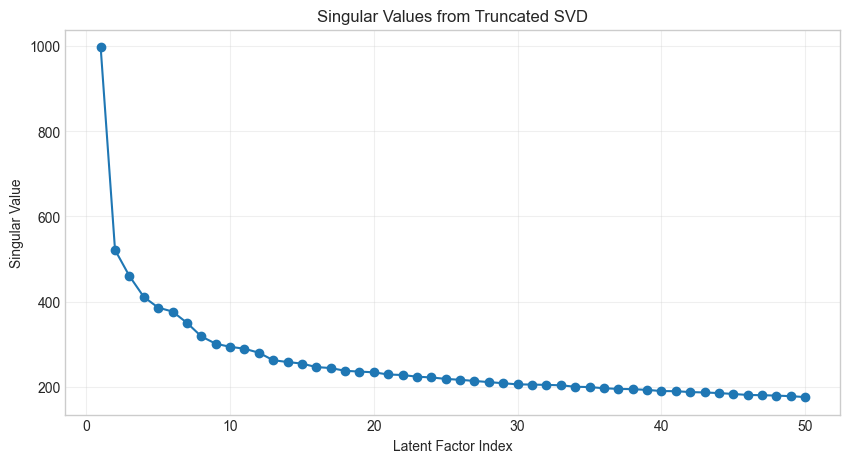

In [146]:
# Valeurs singulières apprises par TruncatedSVD
singular_values = svd.singular_values_

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(singular_values) + 1),
    singular_values,
    marker='o'
)

plt.title('Singular Values from Truncated SVD')
plt.xlabel('Latent Factor Index')
plt.ylabel('Singular Value')
plt.grid(True, alpha=0.3)

plt.show()


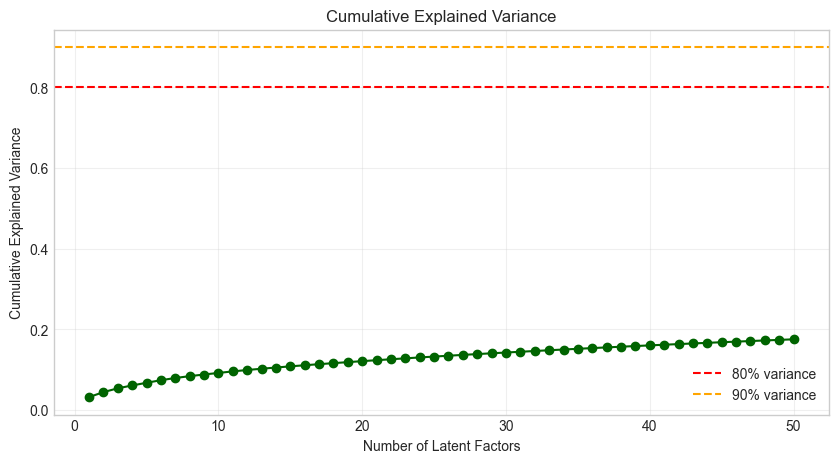

In [147]:
# “How many factors capture most of the information?”
# Variance expliquée cumulée
explained_variance_ratio = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o',
    color='darkgreen'
)

plt.axhline(0.8, color='red', linestyle='--', label='80% variance')
plt.axhline(0.9, color='orange', linestyle='--', label='90% variance')

plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Latent Factors')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


5.4

In [149]:
def get_top_similar_movies_svd(
    item_factors,
    anchor_movie_id,
    movies_df,
    top_k=10
):
    """
    Trouve les top-k films les plus proches d’un film donné
    dans l’espace latent SVD (similarité cosinus).
    """
    # movieId -> index
    anchor_idx = anchor_movie_id - 1

    # Vecteur latent du film anchor (1 x k)
    anchor_vector = item_factors[anchor_idx].reshape(1, -1)

    # Similarité cosinus avec tous les autres films
    similarities = cosine_similarity(anchor_vector, item_factors).flatten()

    # On ignore le film lui-même
    similarities[anchor_idx] = -1

    # Top-k indices
    top_indices = similarities.argsort()[-top_k:][::-1]

    # Conversion indices -> movieId
    top_movie_ids = top_indices + 1

    # Récupération des infos films
    results = movies_df[movies_df['movieId'].isin(top_movie_ids)][
        ['movieId', 'title', 'genres']
    ].copy()

    # Ajouter score de similarité
    results['similarity'] = results['movieId'].apply(
        lambda mid: similarities[mid - 1]
    )

    results = results.sort_values(by='similarity', ascending=False)

    return results


In [150]:
print("=" * 70)
print("5.4 — NEAREST NEIGHBOURS IN LATENT SPACE (SVD)")
print("=" * 70)

svd_neighbors_by_anchor = {}

for title, info in anchor_movies.items():
    print(f"\n🎬 Anchor movie: {title}")
    print("-" * 60)

    svd_neighbors = get_top_similar_movies_svd(
        item_factors=item_factors,
        anchor_movie_id=info['movieId'],
        movies_df=df_movies,
        top_k=10
    )

    svd_neighbors_by_anchor[title] = svd_neighbors
    display(svd_neighbors)


5.4 — NEAREST NEIGHBOURS IN LATENT SPACE (SVD)

🎬 Anchor movie: The Greatest Showman (2017)
------------------------------------------------------------


,movieId,title,genres,similarity
45473,170461,Fog in August (2016),Drama,0.817191
32456,140956,Ready Player One,Action|Sci-Fi|Thriller,0.804465
59296,200540,Aladdin (2019),Adventure|Fantasy|Romance,0.796431
32065,140110,The Intern (2015),Comedy,0.795558
19807,102903,Now You See Me (2013),Crime|Mystery|Thriller,0.790712
37152,152017,Me Before You (2016),Drama|Romance,0.776130
29962,135143,Fantastic Beasts and Where to Find Them (2016),Fantasy,0.772082
39513,157352,The Cutting Edge 3: Chasing the Dream (2008),Comedy|Drama|Romance,0.771157
22578,115667,"Love, Rosie (2014)",Comedy|Romance,0.763004
33522,143355,Wonder Woman (2017),Action|Adventure|Fantasy,0.752418



🎬 Anchor movie: The Lion King (2019)
------------------------------------------------------------


,movieId,title,genres,similarity
39240,156736,NN (2014),(no genres listed),0.782571
57945,197537,Velvet Buzzsaw (2019),Crime|Drama|Horror|Mystery|Thriller,0.767013
29213,133419,Pitch Perfect 2 (2015),Comedy,0.717336
46016,171581,Flower (2017),(no genres listed),0.715504
53533,187613,The Kissing Booth (2018),Comedy|Romance,0.714613
53251,187031,Jurassic World: Fallen Kingdom (2018),Action|Adventure|Drama|Sci-Fi|Thriller,0.714071
47872,175485,Death Note (2017),Horror|Thriller,0.701917
45555,170627,Smurfs: The Lost Village (2017),Adventure|Animation|Children|Comedy,0.699982
44530,168418,The Boss Baby (2017),Animation|Children|Comedy,0.696838
25059,122896,Pirates of the Caribbean: Dead Men Tell No Tal...,(no genres listed),0.695126



🎬 Anchor movie: I Want to Eat Your Pancreas
------------------------------------------------------------


,movieId,title,genres,similarity
42271,163506,Mourning Rock (2000),(no genres listed),0.980643
44040,167384,Casus Belli (2010),(no genres listed),0.979327
45659,170843,Still Life (1997),Documentary,0.974215
50665,181525,Das Himmler Projekt (2000),Documentary,0.973665
19857,103101,Après lui (2007),Drama,0.973472
52227,184833,Hunter in the Dark (1979),Action|Adventure|Drama,0.973305
39293,156862,Sweet Micky for President (2015),Documentary,0.973305
45057,169536,Enemies Within (2016),Drama,0.973147
29009,132967,Thursday Till Sunday (2012),Drama,0.972727
39918,158274,Enamorada (1946),Comedy|Drama|Romance,0.972699


# 6 The Latent Space

6.1

In [151]:
# Extraire le genre principal (premier genre)
df_movies['primary_genre'] = df_movies['genres'].str.split('|').str[0]

# On garde uniquement les films présents dans item_factors
movies_with_factors = df_movies[
    df_movies['movieId'] <= item_factors.shape[0]
].copy()


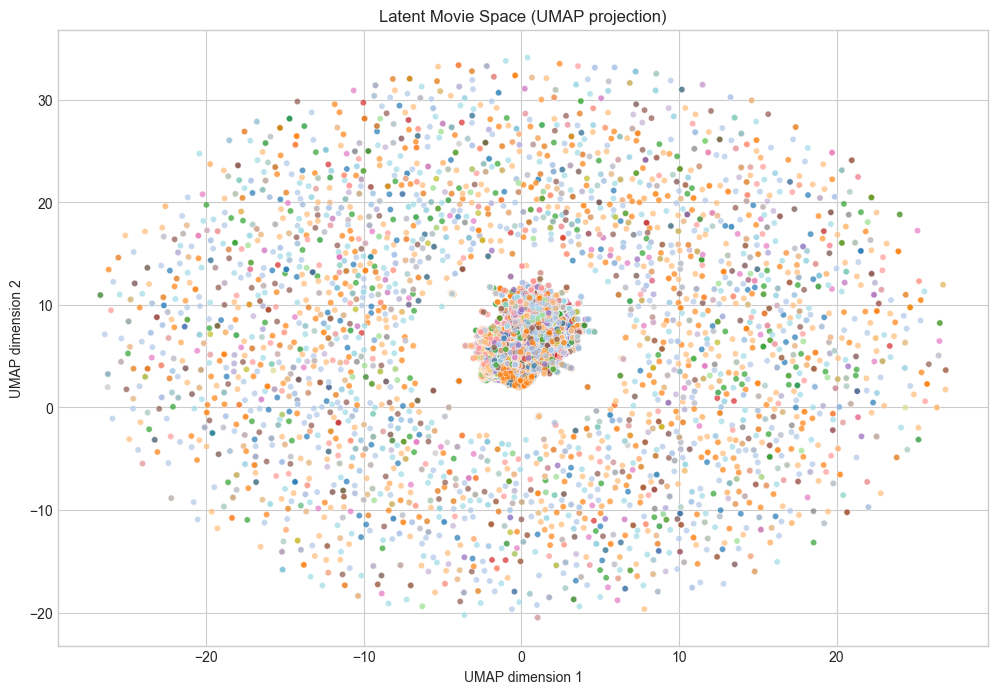

In [153]:
# Réduction à 2 dimensions
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

item_factors_2d = umap_model.fit_transform(item_factors)


# ----- Construire un DataFrame pour la visualisation
latent_2d_df = pd.DataFrame(
    item_factors_2d,
    columns=['x', 'y']
)

latent_2d_df['movieId'] = latent_2d_df.index + 1

latent_2d_df = latent_2d_df.merge(
    movies_with_factors[['movieId', 'title', 'primary_genre']],
    on='movieId',
    how='left'
)

# ---plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=latent_2d_df,
    x='x',
    y='y',
    hue='primary_genre',
    palette='tab20',
    alpha=0.7,
    s=20,
    legend=False  # sinon trop chargé
)

plt.title('Latent Movie Space (UMAP projection)')
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')

plt.show()


6.2

In [154]:
# Récupération des points 2D correspondant aux anchor movies
anchor_points_2d = latent_2d_df[
    latent_2d_df['movieId'].isin(anchor_movie_ids)
].copy()

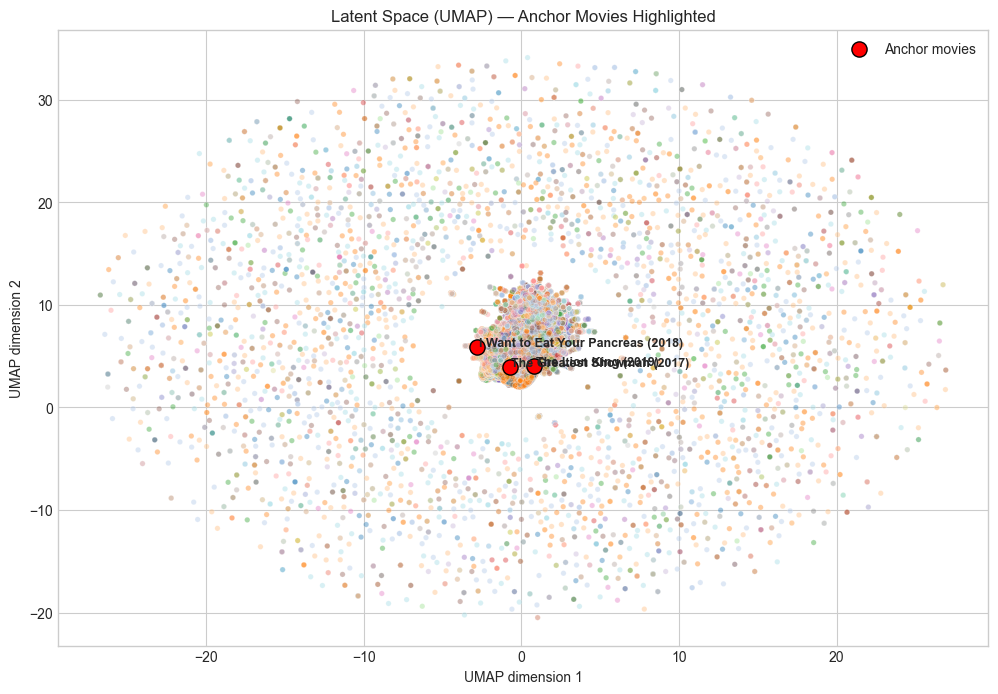

In [155]:
plt.figure(figsize=(12, 8))

# Scatter de tous les films
sns.scatterplot(
    data=latent_2d_df,
    x='x',
    y='y',
    hue='primary_genre',
    palette='tab20',
    alpha=0.4,
    s=15,
    legend=False
)

# Mise en évidence des anchor movies
plt.scatter(
    anchor_points_2d['x'],
    anchor_points_2d['y'],
    color='red',
    s=120,
    edgecolor='black',
    label='Anchor movies'
)

# Annotation des anchor movies
for _, row in anchor_points_2d.iterrows():
    plt.text(
        row['x'] + 0.1,
        row['y'] + 0.1,
        row['title'],
        fontsize=9,
        weight='bold'
    )

plt.title('Latent Space (UMAP) — Anchor Movies Highlighted')
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.legend()

plt.show()


In [156]:
def get_nearest_neighbors_2d(latent_df, anchor_movie_id, top_k=10):
    """
    Trouve les top-k voisins les plus proches d’un film
    dans l’espace latent 2D (distance euclidienne).
    """
    anchor_point = latent_df[latent_df['movieId'] == anchor_movie_id][['x', 'y']].values

    all_points = latent_df[['x', 'y']].values

    distances = cdist(anchor_point, all_points, metric='euclidean').flatten()

    # On ignore le film lui-même
    anchor_idx = anchor_movie_id - 1
    distances[anchor_idx] = np.inf

    nearest_indices = distances.argsort()[:top_k]

    neighbors = latent_df.iloc[nearest_indices][
        ['movieId', 'title', 'primary_genre']
    ].copy()

    neighbors['distance_2d'] = distances[nearest_indices]

    return neighbors


In [159]:
print("=" * 70)
print("6.2 — NEAREST NEIGHBOURS OF ANCHOR MOVIES IN 2D LATENT SPACE")
print("=" * 70)

neighbors_2d_by_anchor = {}

for title, info in anchor_movies.items():
    print(f"\n🎬 Anchor movie: {title}")
    print("-" * 60)

    neighbors_2d = get_nearest_neighbors_2d(
        latent_df=latent_2d_df,
        anchor_movie_id=info['movieId'],
        top_k=10
    )

    neighbors_2d_by_anchor[title] = neighbors_2d
    display(neighbors_2d)


6.2 — NEAREST NEIGHBOURS OF ANCHOR MOVIES IN 2D LATENT SPACE

🎬 Anchor movie: The Greatest Showman (2017)
------------------------------------------------------------


,movieId,title,primary_genre,distance_2d
2279,2280,Clay Pigeons (1998),Crime,0.055240
98,99,Heidi Fleiss: Hollywood Madam (1995),Documentary,0.071901
74794,74795,Green Zone (2010),Action,0.078662
2179,2180,Torn Curtain (1966),Thriller,0.093563
194015,194016,Ralph Breaks the Internet (2018),Animation,0.093599
5054,5055,Dragon: The Bruce Lee Story (1993),Action,0.097228
97187,97188,Sinister (2012),Horror,0.104153
5872,5873,The Emperor's Club (2002),Drama,0.109368
143344,143345,Shazam! (2019),Action,0.111010
152016,152017,Me Before You (2016),Drama,0.116477



🎬 Anchor movie: The Lion King (2019)
------------------------------------------------------------


,movieId,title,primary_genre,distance_2d
71238,71239,"Brøken, The (a.k.a. Broken, The) (2008)",Drama,0.015898
79462,79463,Nanny McPhee Returns (a.k.a. Nanny McPhee and ...,Children,0.015956
3875,3876,Jerry and Tom (1998),Comedy,0.017769
96974,96975,LOL (2012),Comedy,0.019590
7384,7385,Twentynine Palms (2003),Drama,0.025437
8744,8745,"World of Suzie Wong, The (1960)",Drama,0.031532
96366,96367,Hit and Run (Hit & Run) (2012),Action,0.033436
2864,2865,Sugar Town (1999),Comedy,0.039864
44612,44613,Take the Lead (2006),Drama,0.040277
6843,6844,Oleanna (1994),Drama,0.040729



🎬 Anchor movie: I Want to Eat Your Pancreas
------------------------------------------------------------


,movieId,title,primary_genre,distance_2d
165850,165851,Hooligan Sparrow (2016),Documentary,0.015150
167711,167712,The Agha (1985),(no genres listed),0.015298
125210,125211,War and Peace (1965),(no genres listed),0.015405
87993,87994,Gilles' Wife (La femme de Gilles) (2004),Drama,0.016942
59135,59136,Before Flying Back to Earth (Pries parskrendan...,Documentary,0.019545
81058,81059,"Family Friend, The (L'amico di famiglia) (2006)",Drama,0.023129
195262,195263,God Knows Where I Am (2016),Documentary,0.023920
106685,106686,José and Pilar (José e Pilar) (2010),Documentary,0.025368
130979,130980,The Day That Lasted 21 Years (2012),Documentary,0.026423
131750,131751,Cheatin' (2013),Animation,0.026931


6.3

In [160]:
# Genres à analyser (tu peux en changer facilement)
selected_genres = ['Horror', 'Romance', 'Documentary']

# -- filtre 
genre_subset_df = latent_2d_df[
    latent_2d_df['primary_genre'].isin(selected_genres)
].copy()


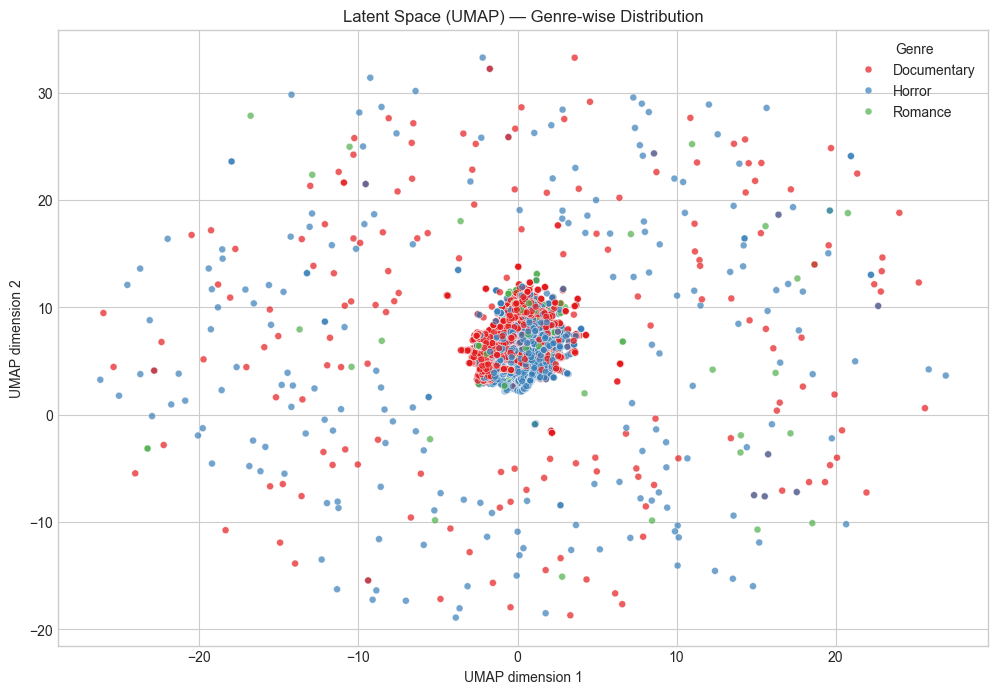

In [161]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=genre_subset_df,
    x='x',
    y='y',
    hue='primary_genre',
    palette='Set1',
    alpha=0.7,
    s=25
)

plt.title('Latent Space (UMAP) — Genre-wise Distribution')
plt.xlabel('UMAP dimension 1')
plt.ylabel('UMAP dimension 2')
plt.legend(title='Genre')

plt.show()


In [162]:
# Mesure simple de dispersion : variance moyenne des coordonnées
genre_dispersion = (
    genre_subset_df
    .groupby('primary_genre')[['x', 'y']]
    .var()
    .mean(axis=1)
    .sort_values()
)

print("=" * 70)
print("6.3 — DISPERSION MOYENNE PAR GENRE (LATENT SPACE)")
print("=" * 70)
print(genre_dispersion)


6.3 — DISPERSION MOYENNE PAR GENRE (LATENT SPACE)
primary_genre
Documentary    10.205930
Horror         14.389326
Romance        16.716938
dtype: float32
